In [286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

In [287]:
x, y = load_diabetes(return_X_y=True)
print("x-shape: ", x.shape)
print("y-shape: ", y.shape)

x-shape:  (442, 10)
y-shape:  (442,)


In [288]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

In [289]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(353, 10)
(89, 10)
(353,)
(89,)


# For Normal Linear Regression

In [290]:
x, y = make_regression(
    n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13
)

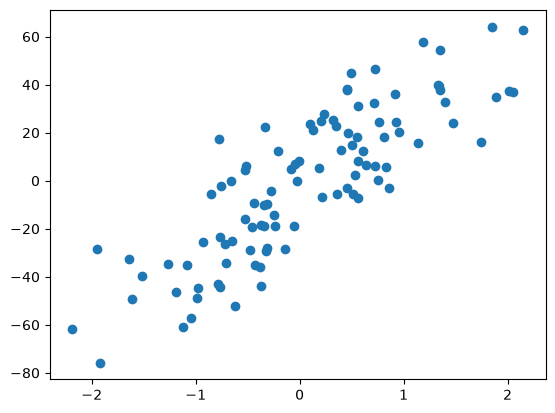

In [291]:
plt.scatter(x, y)

In [292]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [293]:
print("x_train : ", x_train.shape)
print("x_test : ", x_test.shape)
print("y_train : ", y_train.shape)
print("y_test : ", y_test.shape)

x_train :  (80, 1)
x_test :  (20, 1)
y_train :  (80,)
y_test :  (20,)


In [294]:
lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[28.16]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.713
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.36]


In [295]:
y_pred = lr_reg.predict(x_test)
print(r2_score(y_test, y_pred))
print(lr_reg.intercept_)
print(lr_reg.coef_)

0.6186926408914155
-2.7130725669241036
[28.16404017]


In [296]:
class ridge:
    def __init__(self, aplha=0):
        self.alpha = aplha
        self.intercept = None
        self.coef = None

    def model(self, x_train, y_train):
        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            # formula of terms of m solpe
            num += (y_train[i] - y_train.mean()) * (x_train[i] - x_train.mean())
            den += (x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean())

        # Formula of m slope
        self.coef = num / (den + self.alpha)
        self.intercept = y_train.mean() - (self.coef * x_train.mean())

    def predict(self, x_test_poly):
        # y = mx + b
        return self.coef * x_test_poly + self.intercept

0.6186926408914155
-2.7130725669241036
[28.16404017]

In [297]:
ridge = ridge(4)
ridge.model(x_train, y_train)
y_pred = ridge.predict(x_test)
print(r2_score(y_test, y_pred))
print(ridge.intercept)
print(ridge.coef)

0.6212234212217702
[-2.67591549]
[26.63964555]


Text(0.5, 1.0, 'Testing line')

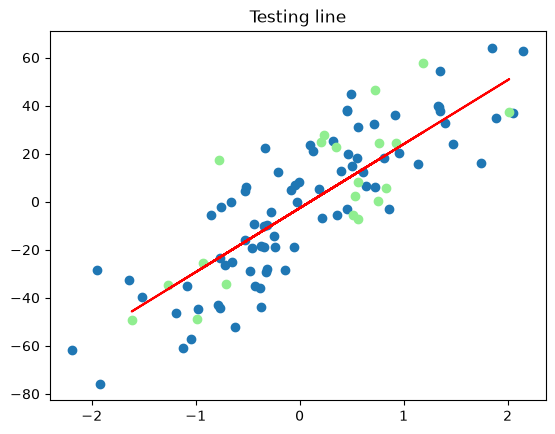

In [298]:
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test, color="lightgreen")
plt.plot(x_test, y_pred, "r")
plt.title("Testing line")

In [299]:
x_new = np.linspace(-3, 3, 100).reshape(100, 1)
y_new = ridge.predict(x_new)
r2_score(x_new, y_new)

-658.731001126437

# For nD Regression

In [300]:
Ridge = Ridge(alpha=0.1, solver="cholesky")
Ridge.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'sa

In [301]:
y_pred = Ridge.predict(x_test)
print(r2_score(y_test, y_pred))
print(Ridge.intercept_)
print(Ridge.coef_)

0.6188165028746301
-2.712091887241781
[28.12380711]


In [302]:
class ridge_nth:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.intercept_ = None
        self.coef_ = None

    def model(self, x_train, y_train):
        x_train = np.insert(x_train, 0, 1, axis=1)
        I = np.identity(x_train.shape[1])
        I[0][0] = 0

        # Here shape of w  is (11, 0) where the first value is of intercept and rest are of solpe of every inputs

        w = (
            np.linalg.inv(np.dot(x_train.T, x_train) + (self.alpha * I))
            .dot(x_train.T)
            .dot(y_train)
        )

        self.intercept_ = w[0]
        self.coef_ = w[1:]

    def predict(self, x_test):
        # Since the sphape of x_test is (89, 10) and self.coef is (10, 0)
        # that's why the x_test are infornt of self.coef
        return np.dot(x_test, self.coef_) + self.intercept_

In [303]:
ridge_nth = ridge_nth(0.2)

0.6188165028746301
-2.712091887241781
[28.12380711]

In [304]:
ridge_nth.model(x_train, y_train)
y_pred = ridge_nth.predict(x_test)
print(r2_score(y_test, y_pred))
print(ridge_nth.intercept_)
print(ridge_nth.coef_)

0.6189369307036185
-2.7111140054153657
[28.08368883]


0.6189369307036185
-2.7111140054153657
[28.08368883]

# Using Gradient

In [305]:
reg = SGDRegressor(
    penalty="l2", max_iter=500, eta0=0.1, learning_rate="constant", alpha=0.001
)

reg.fit(x_train, y_train)

y_pred = reg.predict(x_test)
print("R2 score", r2_score(y_test, y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.6161287493012997
[29.50669889]
[-0.61892013]


In [ ]:
class ridge_GRD:
    def __init__(self, lr, epochs, alpha):
        self.alpha = alpha
        self.lr = lr
        self.epochs = epochs
        self.intercept_ = None
        self.coef_ = None

    def model(self, x_train, y_train):
        x_train = np.insert(x_train, 0, 1, axis=1)
        theta = np.zeros(x_train.shape[1])

        # Gradient formula
        for _ in range(self.epochs):
            # dl/dw = xᵗxw - xᵗy + λw

            theta_der = x_train.T.dot((x_train.dot(theta)) - y_train) + (
                self.alpha * theta
            )
            theta -= self.lr * theta_der

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, x_test):
        # Since the sphape of x_test is (89, 10) and self.coef is (10, 0)
        # that's why the x_test are infornt of self.coef
        return np.dot(x_test, self.coef_) + self.intercept_

In [310]:
ridge_GRD = ridge_GRD(0.005, 500, 0.001)
ridge_GRD.model(x_train, y_train)

In [311]:
y_pred = ridge_GRD.predict(x_test)
print(r2_score(y_test, y_pred))

0.6186940510592605


0.6186940510592602